
# Kagome fRG sanity-check pipeline

This notebook builds a **standard spinful kagome model** using the corrected `channels.py` and `frg_flow.py`, then runs two benchmark interaction points inspired by the PRL phase diagram:

- **FM benchmark:** `U=6, V=0`
- **PI benchmark:** `U=0, V=10`

Target setup:
- no flux
- van Hove filling proxy: `mu = 0`
- `Npatch = 12`

The purpose is simple:

1. verify the corrected longitudinal channel construction in a full end-to-end pipeline  
2. check whether the final leading instability looks **FM-like** for large `U`  
3. check whether it looks **PI-like** for large `V`  

If the second case still does **not** show PI-like structure, the next place to inspect is likely:
- `form_factor.py`
- `kagome_order_diagnosis.py`

---


In [1]:

import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver



## 1. Global parameters

You can tune the flow resolution here.

Notes:
- `mu=0` matches the PRL convention for kagome VHF.
- `band_index=1` is the dispersive band crossing `mu=0` inside each 3x3 spin block.
- `Npatch=12` is intentionally small, just for a fast pipeline sanity check.
- For a more reliable final physics check, increase `Npatch`, `nfreq`, and `n_steps`.


In [2]:

# ---------- noninteracting / patching ----------
MODEL_PARAMS = dict(t=1.0, phi=0.0)   # standard kagome = phi=0
MU = 0.0
NPATCH = 6
GRID_SIZE = 220
CONTOUR_MIN_POINTS = 40

# Each spin block is 3x3 inside the full 6x6 spinful Hamiltonian
UP_SLICE = slice(0, 3)
DN_SLICE = slice(3, 6)
LOCAL_BAND_INDEX = 1   # dispersive band crossing mu=0

# ---------- flow ----------
FLOW_KWARGS = dict(
    T_start=0.5,
    T_stop=0.01,
    n_steps=200,
    nfreq=10,
    diagnose_every=10,
    temperature_grid="log",
    include_explicit_T_prefactor=True,
    max_relative_update=1,
    min_substep_fraction=0.1,
    channel_divergence_threshold=1e5,
    eigenvalue_threshold=1e5,
    diagnosis_sort_by="abs",
    track_crossed_channel=True,
#     diagnosis_Qs = [np.array([0.0, 0.0]), np.pi * np.array([-0.5, -np.sqrt(3)/2]), np.pi * np.array([ 1.0,  0.0]), np.pi * np.array([-0.5,  np.sqrt(3)/2])]
# )
    diagnosis_Qs = [np.array([0.0, 0.0]), np.array([0.0,  np.pi/np.sqrt(3)]), np.array([ np.pi/2,  np.pi/(2*np.sqrt(3))]), np.array([-np.pi/2,  np.pi/(2*np.sqrt(3))])]
)

## 2. Build the standard spinful kagome model and the two spin patchsets

Patch counts: {'up': 6, 'dn': 6}
mu used for contour (up/dn): 0.0005 0.0005
gauge loop phase (up/dn): -1.2246467991473532e-16 -1.2246467991473532e-16

===== ORIGINAL FS PATCHSET =====

--- up patchset ---
Npatch = 6
mu = 0.0
mu_used_for_contour = 0.0005
gauge_method = parallel_transport
gauge_loop_phase = -1.2246467991473532e-16

patch details:
id=0 | k=[-0.017789  1.803529] | E=4.362710e-18 | |vF|=7.114e-02 | w=[9.997e-01 0.000e+00 3.000e-04]
id=1 | k=[-1.570796  0.886159] | E=4.398395e-18 | |vF|=7.183e-02 | w=[0.000e+00 3.000e-04 9.997e-01]
id=2 | k=[-1.552876 -0.917246] | E=-3.469447e-18 | |vF|=7.167e-02 | w=[3.000e-04 9.997e-01 0.000e+00]
id=3 | k=[ 0.016434 -1.804311] | E=4.025362e-18 | |vF|=6.572e-02 | w=[9.997e-01 0.000e+00 3.000e-04]
id=4 | k=[ 1.570796 -0.887797] | E=4.051198e-18 | |vF|=6.616e-02 | w=[0.000e+00 3.000e-04 9.997e-01]
id=5 | k=[1.554368 0.916385] | E=3.469447e-18 | |vF|=6.570e-02 | w=[3.000e-04 9.997e-01 0.000e+00]

--- dn patchset ---
Npatch = 6
mu = 0.0
mu_used

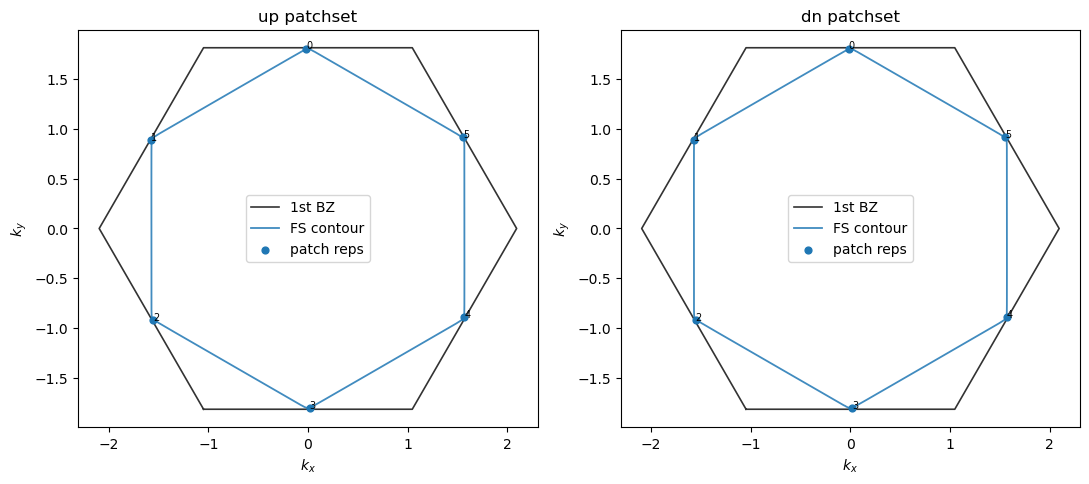

In [11]:

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

def build_patchsets(model, mu=0.0, npatch=12, grid_size=220, contour_min_points=40):
    patch_up = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=UP_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=LOCAL_BAND_INDEX,
        mu=mu,
        Npatch=npatch,
        grid_size=grid_size,
        orbital_slice=DN_SLICE,
        contour_min_points=contour_min_points,
        gauge_fix="parallel_transport",
        verbose=False,
        # auto_level_shifts = [0],
    ).build()

    return {"up": patch_up, "dn": patch_dn}

patchsets = build_patchsets(
    model,
    mu=MU,
    npatch=NPATCH,
    grid_size=GRID_SIZE,
    contour_min_points=CONTOUR_MIN_POINTS,
)

print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge loop phase (up/dn):", patchsets["up"].gauge_loop_phase, patchsets["dn"].gauge_loop_phase)

print("\n===== ORIGINAL FS PATCHSET =====")

for spin in ["up", "dn"]:
    ps = patchsets[spin]

    print(f"\n--- {spin} patchset ---")
    print(f"Npatch = {ps.Npatch}")
    print(f"mu = {ps.mu}")
    print(f"mu_used_for_contour = {ps.mu_used_for_contour}")
    print(f"gauge_method = {ps.gauge_method}")
    print(f"gauge_loop_phase = {ps.gauge_loop_phase}")

    print("\npatch details:")
    for p in ps.patches:
        print(
            f"id={p.patch_id} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"E={p.energy:.6e} | "
            f"|vF|={p.vF_norm:.3e} | "
            f"w={np.round(p.orbital_weight, 4)}"
        )


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_patchset(patchsets["up"], ax=axes[0], show_contour=True, show_velocity=False, show_bz=True)
axes[0].set_title("up patchset")
plot_patchset(patchsets["dn"], ax=axes[1], show_contour=True, show_velocity=False, show_bz=True)
axes[1].set_title("dn patchset")
plt.tight_layout()
plt.show()


## 3. Helpers for running a benchmark interaction point

In [12]:
from frg_flow import FRGFlowSolver

_old_step = FRGFlowSolver.step
_old_run = FRGFlowSolver.run

def _debug_step(self, T_old, dT):
    print(f"[DEBUG] entering step: T_old={T_old:.8f}, dT={dT:.8e}")
    try:
        rec = _old_step(self, T_old, dT)
        print(
            f"[DEBUG] leaving step: "
            f"T_new={getattr(rec, 'temperature', float(T_old + dT)):.8f}, "
            f"rhs_norm={getattr(rec, 'rhs_norm', None)}, "
            f"channel_norm={getattr(rec, 'channel_norm', None)}, "
            f"accepted_substeps={getattr(rec, 'accepted_substeps', None)}, "
            f"max_rel_update={getattr(rec, 'max_rel_update', None)}"
        )
        return rec
    except Exception as e:
        print(f"[DEBUG] exception in step:")
        print(f"        T_old = {T_old:.8f}")
        print(f"        dT    = {dT:.8e}")
        print(f"        T_new = {T_old + dT:.8f}")
        raise

def _debug_run(self):
    # print("[DEBUG] temperature path:")
    # for i, T in enumerate(self.temperature_path):
    #     print(f"  i={i:03d}, T={float(T):.8f}")
    return _old_run(self)

FRGFlowSolver.step = _debug_step
FRGFlowSolver.run = _debug_run

def build_solver(model, patchsets, U, V, flow_kwargs=None):
    flow_kwargs = {} if flow_kwargs is None else dict(flow_kwargs)
    interaction = BareExtendedHubbard.from_kagome_model(model, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        **flow_kwargs,
    )
    return interaction, bare_gamma, solver


def summarize_history(history):
    rows = []
    for rec in history:
        rows.append({
            "step": rec.step_index,
            "T": rec.temperature,
            "channel_norm": rec.channel_norm,
            "rhs_norm": rec.rhs_norm,
            "leading_channel": rec.leading_channel_name,
            "leading_order": rec.leading_order_label,
            "leading_abs_eval": rec.leading_eigenvalue_abs,
            "instability": rec.instability,
            "reason": rec.instability_reason,
        })
    return rows


def pretty_print_final_record(history):
    rec = history[-1]
    print("===== Final record =====")
    pprint(rec.summary_dict())
    return rec


def plot_history(history, title):
    steps = [h.step_index for h in history]
    Ts = [h.temperature for h in history]
    evals = [np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs for h in history]
    norms = [h.channel_norm for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(steps, evals, marker="o")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("leading |eigenvalue|")
    axes[0].set_title(f"{title}: leading eigenvalue")

    axes[1].plot(steps, norms, marker="o")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("channel norm")
    axes[1].set_title(f"{title}: channel norm")

    plt.tight_layout()
    plt.show()


def run_case(case_name, U, V, flow_kwargs=None):
    print(f"\n===== Running case: {case_name} (U={U}, V={V}) =====")
    interaction, bare_gamma, solver = build_solver(
        model=model,
        patchsets=patchsets,
        U=U,
        V=V,
        flow_kwargs=flow_kwargs if flow_kwargs is not None else FLOW_KWARGS,
    )
    history = solver.run()
    print(f"history length = {len(history)}")
    print(f"instability record = {None if solver.instability_record is None else solver.instability_record.step_index}")
    final_rec = pretty_print_final_record(history)
    plot_history(history, case_name)
    return {
        "case_name": case_name,
        "U": U,
        "V": V,
        "interaction": interaction,
        "solver": solver,
        "history": history,
        "final_record": final_rec,
    }



## 4. FM benchmark: `U=6, V=0`

Expectation from the PRL benchmark at van Hove filling:
- dominant onsite interaction should favor **ferromagnetism (FM)**.



===== Running case: FM benchmark (U=0.0, V=6.0) =====
[DEBUG] entering step: T_old=0.50000000, dT=-9.73322028e-03
[DEBUG] leaving step: T_new=0.49026678, rhs_norm=2258.190710001826, channel_norm=21.97946760898034, accepted_substeps=2, max_rel_update=0.9160582872065994
[DEBUG] entering step: T_old=0.49026678, dT=-9.54374912e-03
[DEBUG] leaving step: T_new=0.48072303, rhs_norm=13777.142384899122, channel_norm=153.46502864617713, accepted_substeps=6, max_rel_update=0.9970334806691105
[DEBUG] entering step: T_old=0.48072303, dT=-9.35796630e-03
[DEBUG] leaving step: T_new=0.48072303, rhs_norm=559230.3630218374, channel_norm=153.46502864617713, accepted_substeps=0, max_rel_update=34.10066082447204
[FRGFlowSolver] Adaptive step control requested too many substeps; stopping flow early and returning partial history. Current state remains at T=0.48072303, attempted T_new=0.47136506, rhs_norm=5.592e+05, rel_update=3.410e+01, proposed_n_sub=35. Reduce temperature spacing or relax max_relative_upd

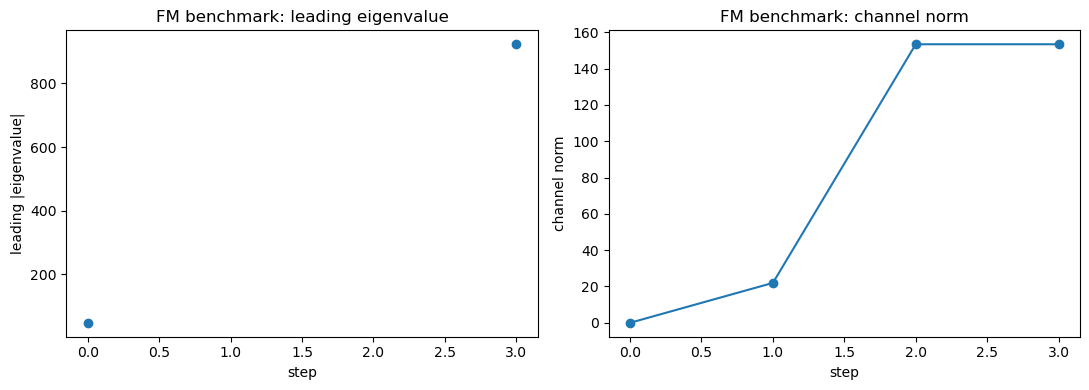

In [8]:

fm_result = run_case("FM benchmark", U=0.0, V=6.0, flow_kwargs=FLOW_KWARGS)


===== Final-state diagnosis across all Q =====

===== Q[0] = [0. 0.] =====
pp_singlet_sz0             |eig|max = 0
pp_triplet_sz0             |eig|max = 0
ph_charge_longitudinal     |eig|max = 635.04494
ph_spin_longitudinal       |eig|max = 923.1476
--> leading channel at this Q: ph_spin_longitudinal  (|eig|max = 923.1476)

===== Q[1] = [0.         1.81379936] =====
pp_singlet_sz0             |eig|max = 312.81028
pp_triplet_sz0             |eig|max = 312.81028
ph_charge_longitudinal     |eig|max = 312.81425
ph_spin_longitudinal       |eig|max = 6.0185311e-36
--> leading channel at this Q: ph_charge_longitudinal  (|eig|max = 312.81425)

===== Q[2] = [1.57079633 0.90689968] =====
pp_singlet_sz0             |eig|max = 312.80996
pp_triplet_sz0             |eig|max = 312.80996
ph_charge_longitudinal     |eig|max = 312.81407
ph_spin_longitudinal       |eig|max = 1.2037062e-35
--> leading channel at this Q: ph_charge_longitudinal  (|eig|max = 312.81407)

===== Q[3] = [-1.57079633  0.90689968]

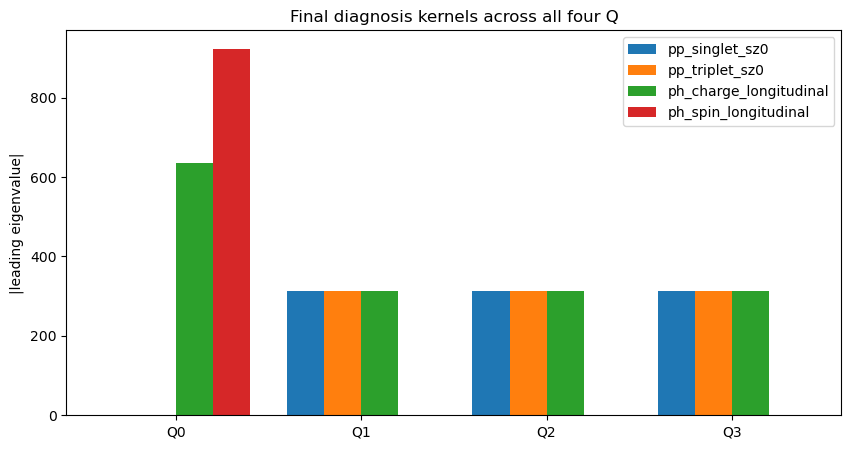


==== pp_singlet_sz0 ====
Q = [0. 0.]
|eig|max = 0.0
vec.real = [1. 0. 0. 0. 0. 0.]
vec.abs  = [1. 0. 0. 0. 0. 0.]

==== pp_triplet_sz0 ====
Q = [0. 0.]
|eig|max = 0.0
vec.real = [1. 0. 0. 0. 0. 0.]
vec.abs  = [1. 0. 0. 0. 0. 0.]

==== ph_charge_longitudinal ====
Q = [0. 0.]
|eig|max = 635.0449363678987
vec.real = [0.40824714 0.40824754 0.40824705 0.40824913 0.40824964 0.40824925]
vec.abs  = [0.40824714 0.40824754 0.40824705 0.40824913 0.40824964 0.40824925]

==== ph_spin_longitudinal ====
Q = [0. 0.]
|eig|max = 923.1476021724488
vec.real = [0.40824564 0.4082464  0.40824533 0.40825039 0.40825141 0.40825058]
vec.abs  = [0.40824564 0.4082464  0.40824533 0.40825039 0.40825141 0.40825058]


In [9]:
# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]

channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = fm_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))


## 5. PI benchmark: `U=0, V=10`

Expectation from the PRL benchmark at van Hove filling:
- dominant nearest-neighbor repulsion should favor **Pomeranchuk instability (PI)** with d-wave character.

If this still does **not** look PI-like, then the likely next suspects are:
- `form_factor.py`
- `kagome_order_diagnosis.py`


In [12]:

pi_result = run_case("PI benchmark", U=0.0, V=10.0, flow_kwargs=FLOW_KWARGS)


NameError: name 'run_case' is not defined

In [13]:

solver = pi_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

# 你现在 flow_kwargs 里已经有 diagnosis_Qs
Qs_to_check = FLOW_KWARGS["diagnosis_Qs"]

channels_to_check = [
    "pp_singlet_sz0",
    "pp_triplet_sz0",
    "ph_charge_longitudinal",
    "ph_spin_longitudinal",
]
solver = fm_result["solver"]
print("===== Final-state diagnosis across all Q =====")
for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    print(f"\n===== Q[{i}] = {Q} =====")
    vals_dict = {}

    for name in channels_to_check:
        k = kernels[name]
        vals, vecs = k.eig(sort_by="abs")
        eigmax = abs(vals[0])
        vals_dict[name] = eigmax
        print(f"{name:26s} |eig|max = {eigmax:.8g}")

    lead_name = max(vals_dict, key=vals_dict.get)
    print(f"--> leading channel at this Q: {lead_name}  (|eig|max = {vals_dict[lead_name]:.8g})")
Q_summary = []

for i, Q in enumerate(Qs_to_check):
    Q = np.asarray(Q, dtype=float)
    kernels = solver.build_diagnosis_kernel_dict(Q)

    row = {
        "Q_index": i,
        "Q_vec": Q,
    }

    for name in channels_to_check:
        vals, _ = kernels[name].eig(sort_by="abs")
        row[name] = float(abs(vals[0]))

    row["leading_channel"] = max(channels_to_check, key=lambda name: row[name])
    row["leading_value"] = row[row["leading_channel"]]
    Q_summary.append(row)

Q_summary

import matplotlib.pyplot as plt
import numpy as np

labels = [f"Q{i}" for i in range(len(Q_summary))]
x = np.arange(len(labels))
width = 0.2

pp_s = [row["pp_singlet_sz0"] for row in Q_summary]
pp_t = [row["pp_triplet_sz0"] for row in Q_summary]
ph_c = [row["ph_charge_longitudinal"] for row in Q_summary]
ph_s = [row["ph_spin_longitudinal"] for row in Q_summary]

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5*width, pp_s, width, label="pp_singlet_sz0")
plt.bar(x - 0.5*width, pp_t, width, label="pp_triplet_sz0")
plt.bar(x + 0.5*width, ph_c, width, label="ph_charge_longitudinal")
plt.bar(x + 1.5*width, ph_s, width, label="ph_spin_longitudinal")

plt.xticks(x, labels)
plt.ylabel("|leading eigenvalue|")
plt.title("Final diagnosis kernels across all four Q")
plt.legend()
plt.show()
# solver = fm_result["solver"]
Q = np.array([0.0, 0.0])
kernels = solver.build_diagnosis_kernel_dict(Q)
# for name, k in kernels.items():
#     vals, vecs = k.eig(sort_by="abs")
#     print(f"{name:25s}  |eig|max = {abs(vals[0]):.6g}")

for name in ["pp_singlet_sz0", "pp_triplet_sz0", "ph_charge_longitudinal", "ph_spin_longitudinal"]:
    k = kernels[name]
    vals, vecs = k.eig(sort_by="abs")
    print(f"\n==== {name} ====")
    print("Q =", k.Q)
    print("|eig|max =", abs(vals[0]))
    print("vec.real =", np.real(vecs[:, 0]))
    print("vec.abs  =", np.abs(vecs[:, 0]))

NameError: name 'pi_result' is not defined

## 6. Compact side-by-side summary

In [ ]:

def compact_case_summary(result):
    rec = result["final_record"]
    return {
        "case": result["case_name"],
        "U": result["U"],
        "V": result["V"],
        "leading_channel": rec.leading_channel_name,
        "leading_order": rec.leading_order_label,
        "leading_abs_eval": rec.leading_eigenvalue_abs,
        "channel_norm": rec.channel_norm,
        "instability": rec.instability,
        "instability_reason": rec.instability_reason,
    }

summary = [
    compact_case_summary(fm_result),
    compact_case_summary(pi_result),
]

for row in summary:
    pprint(row)



## 7. Optional: inspect the raw diagnosis payloads

This is useful when:
- the FM case is reasonable but the PI case is not
- or the final `leading_order_label` is too coarse / ambiguous


In [ ]:

print("===== FM diagnosis payload =====")
pprint(fm_result["final_record"].diagnosis_payload)

print("\n===== PI diagnosis payload =====")
pprint(pi_result["final_record"].diagnosis_payload)



## 8. What to conclude from the outcomes

### If you get:
- `U=6, V=0` → FM-like
- `U=0, V=10` → PI-like

then the corrected `channels.py` + `frg_flow.py` have likely fixed the main bug, and the whole pipeline is much closer to the target PRL behavior.

### If you get:
- FM benchmark looks reasonable
- PI benchmark still does **not** become PI-like

then the next things to debug are likely:
1. **form-factor projection**
2. **PI degeneracy handling**
3. **kagome-specific diagnosis templates**

and only after that would I go back and seriously suspect the one-loop kernel again.
